
# Exploratory Data Analysis (EDA) — Skrining Diabetes Indonesia

Dataset: BRFSS 2015  
Fokus EDA:
- Q1 Faktor Risiko Utama
- Q2 Gaya Hidup & Kebiasaan
- Q3 Demografis Usia & BMI
- Q4 Komorbiditas Klinis
- Q5 Sosial-Ekonomi & Akses Kesehatan

Tujuan utama tahap EDA adalah memahami pola data, hubungan antar variabel, distribusi prevalensi diabetes, serta menghasilkan insight awal sebelum tahap feature engineering dan modeling dilakukan.


# 1. Import Library

In [ ]:

# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")


Library berhasil diimport.


# 2. Load Dataset

In [ ]:
# =========================================================
# LOAD CLEAN DATASET HASIL DATA WRANGLING
# =========================================================
#dataset yang digunakan merupakan dataset hasil data wrangling

file_id = "1yx8Mw1B0HXJs8BMLNeXjRXIC2A8S_NEA"

url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

print("Dataset hasil data wrangling berhasil dimuat.")
print(f"Ukuran dataset: {df.shape}")

display(df.head())

Dataset hasil data wrangling berhasil dimuat.
Ukuran dataset: (70692, 17)


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Income,NoDocbcCost,Diabetes_binary
0,1,0,26.0,0,0,0,1,1,0,3.0,5.0,30.0,0,4,8,0,0
1,1,1,26.0,1,1,0,0,0,0,3.0,0.0,0.0,0,12,8,0,0
2,0,0,26.0,0,0,0,1,1,0,1.0,0.0,10.0,0,13,8,0,0
3,1,1,28.0,1,0,0,1,1,0,3.0,0.0,3.0,0,11,8,0,0
4,0,0,29.0,1,0,0,1,1,0,2.0,0.0,0.0,0,8,8,0,0


# Q1 — Faktor Risiko Utama

## Pertanyaan Bisnis

Dari 16 indikator kesehatan terpilih, faktor risiko mana yang paling signifikan membedakan penderita dan non-penderita diabetes pada data BRFSS 2015, dan seberapa besar kontribusi relatif masing-masing faktor yang dapat diukur melalui nilai korelasi statistik?

## Tujuan Analisis

Analisis ini bertujuan untuk mengidentifikasi indikator kesehatan yang memiliki hubungan paling kuat dengan status diabetes.

Dengan mengetahui faktor yang paling berpengaruh, sistem skrining yang akan dikembangkan dapat memprioritaskan variabel yang memiliki kemampuan diskriminatif paling tinggi dalam membedakan kelompok diabetes dan non-diabetes.

## Metode Analisis

Hubungan antara setiap indikator kesehatan dan status diabetes diukur menggunakan korelasi Pearson.

Nilai korelasi absolut digunakan untuk membandingkan kekuatan hubungan antar fitur. Semakin besar nilai korelasi, semakin besar kontribusi relatif fitur tersebut dalam menjelaskan perbedaan status diabetes.

In [ ]:

# =========================================================
# KORELASI TERHADAP TARGET
# =========================================================

correlation = df.corr()['Diabetes_binary'].drop('Diabetes_binary')

correlation_df = pd.DataFrame({
    'Fitur': correlation.index,
    'Nilai Korelasi |r|': correlation.abs().values
})

correlation_df = correlation_df.sort_values(
    by='Nilai Korelasi |r|',
    ascending=False
)

display(correlation_df)

,Fitur,Nilai Korelasi |r|
9,GenHlth,0.407612
0,HighBP,0.381516
2,BMI,0.293373
1,HighChol,0.289213
13,Age,0.278738
12,DiffWalk,0.272646
14,Income,0.224449
11,PhysHlth,0.213081
5,HeartDiseaseorAttack,0.211523
6,PhysActivity,0.158666


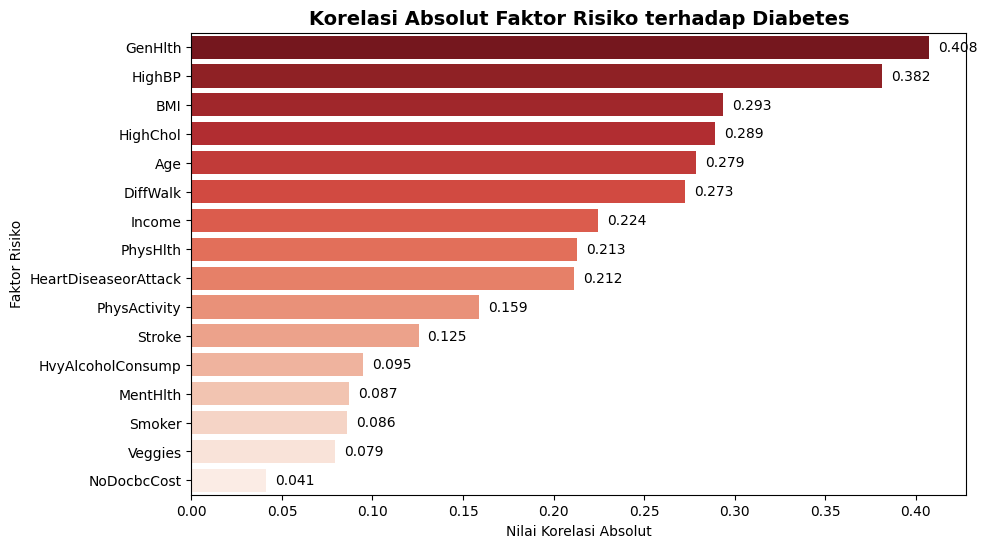

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=correlation_df,
    x='Nilai Korelasi |r|',
    y='Fitur',
    palette='Reds_r'
)

for i, v in enumerate(correlation_df['Nilai Korelasi |r|']):
    ax.text(
        v + 0.005,
        i,
        f'{v:.3f}',
        va='center'
    )

plt.title(
    'Korelasi Absolut Faktor Risiko terhadap Diabetes',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Nilai Korelasi Absolut')
plt.ylabel('Faktor Risiko')

plt.show()

Insight

Analisis korelasi menunjukkan bahwa setiap indikator kesehatan memiliki kekuatan hubungan yang berbeda terhadap status diabetes. Berdasarkan nilai korelasi absolut, lima faktor dengan hubungan terkuat terhadap diabetes adalah GenHlth (|r| = 0,4076), HighBP (|r| = 0,3815), BMI (|r| = 0,2934), HighChol (|r| = 0,2892), dan Age (|r| = 0,2787).

GenHlth memiliki nilai korelasi tertinggi, yang menunjukkan bahwa kondisi kesehatan umum responden merupakan indikator yang paling mampu membedakan kelompok diabetes dan non-diabetes pada dataset ini. Semakin buruk kondisi kesehatan yang dilaporkan responden, semakin sering responden tersebut ditemukan pada kelompok diabetes.

HighBP berada pada posisi kedua dengan nilai korelasi yang sangat dekat dengan GenHlth. Temuan ini menunjukkan bahwa hipertensi merupakan salah satu karakteristik yang paling sering ditemukan pada kelompok diabetes dalam data BRFSS 2015.

BMI dan HighChol juga menunjukkan hubungan yang cukup kuat. Hal ini menunjukkan bahwa faktor metabolik seperti obesitas dan kolesterol tinggi memiliki hubungan yang jelas dengan status diabetes pada populasi yang diamati.

Age menempati posisi kelima, yang mengindikasikan bahwa prevalensi diabetes cenderung lebih tinggi pada kelompok usia yang lebih tua dibandingkan kelompok usia yang lebih muda.

Sebaliknya, faktor gaya hidup seperti PhysActivity (|r| = 0,1587), Smoker (|r| = 0,0860), Veggies (|r| = 0,0783), dan HvyAlcoholConsump (|r| = 0,0949) memiliki korelasi yang lebih rendah. Hasil ini menunjukkan bahwa kemampuan faktor-faktor tersebut dalam membedakan kelompok diabetes dan non-diabetes lebih kecil dibandingkan faktor klinis yang diamati pada dataset ini.

Implikasi Bisnis

Hasil analisis menunjukkan bahwa sistem skrining diabetes sebaiknya memberikan perhatian lebih besar pada indikator klinis seperti hipertensi, BMI, kolesterol tinggi, usia, dan kondisi kesehatan umum karena variabel-variabel tersebut memiliki hubungan yang paling kuat dengan status diabetes.

Selain itu, hasil ini juga menjadi dasar yang kuat dalam pemilihan fitur untuk model machine learning karena fitur dengan korelasi yang lebih tinggi umumnya memiliki kemampuan yang lebih baik dalam membedakan kelompok risiko.

Kesimpulan

Faktor yang paling signifikan dalam membedakan penderita dan non-penderita diabetes pada dataset BRFSS 2015 adalah GenHlth, HighBP, BMI, HighChol, dan Age. Kelima faktor tersebut memiliki kontribusi relatif terbesar berdasarkan nilai korelasi statistik yang diperoleh.

# Q2 — Gaya Hidup dan Kebiasaan

## Pertanyaan Bisnis

Apakah individu yang tidak aktif secara fisik dan jarang mengonsumsi sayuran memiliki proporsi penderita diabetes yang secara statistik signifikan lebih tinggi dibandingkan individu yang aktif dan rutin mengonsumsi sayuran?

## Tujuan Analisis

Analisis ini bertujuan untuk mengevaluasi hubungan antara kebiasaan hidup sehat dengan prevalensi diabetes.

Hasil analisis diharapkan dapat memberikan gambaran apakah aktivitas fisik dan pola konsumsi sayuran berhubungan dengan tingkat kejadian diabetes pada populasi yang diamati.

## Metode Analisis

Responden dikelompokkan berdasarkan kombinasi aktivitas fisik dan konsumsi sayuran.

Prevalensi diabetes dihitung untuk setiap kelompok, kemudian dilakukan uji Chi-Square untuk mengetahui apakah perbedaan yang ditemukan signifikan secara statistik atau hanya terjadi karena variasi acak pada data.

In [ ]:

# =========================================================
# KOMBINASI GAYA HIDUP
# =========================================================

lifestyle_table = pd.crosstab(
    [df['PhysActivity'], df['Veggies']],
    df['Diabetes_binary'],
    normalize='index'
) * 100

lifestyle_table.columns = ['Non Diabetes (%)', 'Diabetes (%)']

display(lifestyle_table)

# Chi-square test
contingency = pd.crosstab(
    [df['PhysActivity'], df['Veggies']],
    df['Diabetes_binary']
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("="*60)
print("HASIL CHI-SQUARE TEST")
print("="*60)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p:.6f}")


Non Diabetes (%)  Diabetes (%)
PhysActivity Veggies                                
0            0               34.936748     65.063252
             1               39.047293     60.952707
1            0               47.895416     52.104584
             1               56.660189     43.339811

HASIL CHI-SQUARE TEST
Chi-square statistic : 2026.8378
P-value              : 0.000000


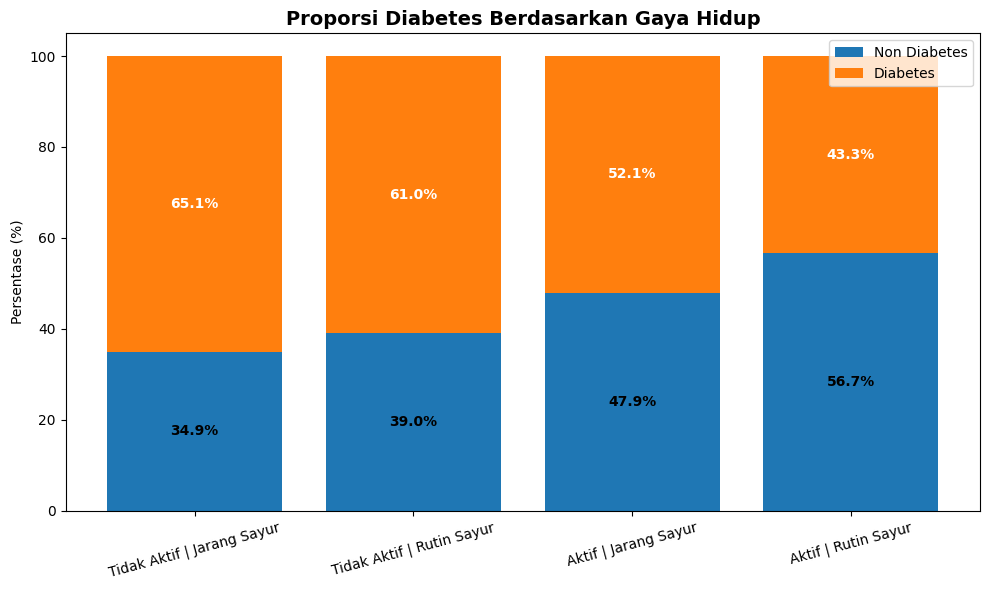

In [ ]:
lifestyle_plot = lifestyle_table.reset_index()

lifestyle_plot['Kelompok'] = (
    lifestyle_plot['PhysActivity'].map({
        0:'Tidak Aktif',
        1:'Aktif'
    })
    + ' | ' +
    lifestyle_plot['Veggies'].map({
        0:'Jarang Sayur',
        1:'Rutin Sayur'
    })
)

plt.figure(figsize=(10,6))

bars1 = plt.bar(
    lifestyle_plot['Kelompok'],
    lifestyle_plot['Non Diabetes (%)'],
    label='Non Diabetes'
)

bars2 = plt.bar(
    lifestyle_plot['Kelompok'],
    lifestyle_plot['Diabetes (%)'],
    bottom=lifestyle_plot['Non Diabetes (%)'],
    label='Diabetes'
)

# Label Non Diabetes
for bar in bars1:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height/2,
        f'{height:.1f}%',
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Label Diabetes
for bar, bottom in zip(
    bars2,
    lifestyle_plot['Non Diabetes (%)']
):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bottom + height/2,
        f'{height:.1f}%',
        ha='center',
        va='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

plt.title(
    'Proporsi Diabetes Berdasarkan Gaya Hidup',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Persentase (%)')

plt.legend()

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

Q2 — Gaya Hidup dan Kebiasaan
Insight

Hasil analisis menunjukkan bahwa terdapat perbedaan prevalensi diabetes yang cukup besar antar kelompok gaya hidup yang diamati.

Kelompok yang tidak aktif secara fisik dan tidak rutin mengonsumsi sayuran memiliki prevalensi diabetes tertinggi sebesar 65,06%. Artinya, sekitar dua dari tiga individu pada kelompok tersebut merupakan penderita diabetes.

Sebaliknya, kelompok yang aktif secara fisik dan rutin mengonsumsi sayuran memiliki prevalensi diabetes terendah sebesar 43,34%. Selisih antara kedua kelompok mencapai 21,72 poin persentase, yang menunjukkan adanya perbedaan yang cukup besar dalam prevalensi diabetes.

Jika diamati lebih rinci, kelompok yang aktif secara fisik secara konsisten memiliki prevalensi diabetes yang lebih rendah dibandingkan kelompok yang tidak aktif secara fisik. Pada kelompok yang tidak rutin mengonsumsi sayuran, prevalensi diabetes turun dari 65,06% menjadi 52,10% ketika individu aktif secara fisik.

Konsumsi sayuran juga menunjukkan pola yang serupa. Pada kelompok yang aktif secara fisik, prevalensi diabetes turun dari 52,10% menjadi 43,34% ketika responden rutin mengonsumsi sayuran.

Uji Chi-Square menghasilkan nilai statistik sebesar 2026,84 dengan p-value < 0,001. Hasil ini menunjukkan bahwa perbedaan prevalensi diabetes antar kelompok gaya hidup bersifat signifikan secara statistik dan sangat kecil kemungkinannya terjadi secara kebetulan.

Implikasi Bisnis

Aktivitas fisik dan konsumsi sayuran merupakan informasi yang relatif mudah diperoleh dari pengguna tanpa memerlukan pemeriksaan medis. Oleh karena itu, kedua variabel ini sangat cocok digunakan sebagai komponen skrining awal untuk membantu mengidentifikasi kelompok dengan prevalensi diabetes yang lebih tinggi.

Selain itu, hasil ini menunjukkan bahwa faktor gaya hidup tetap memberikan informasi tambahan yang relevan meskipun kekuatan hubungannya lebih rendah dibandingkan faktor klinis.

Kesimpulan

Individu yang tidak aktif secara fisik dan jarang mengonsumsi sayuran memiliki prevalensi diabetes yang secara signifikan lebih tinggi dibandingkan individu yang aktif secara fisik dan rutin mengonsumsi sayuran. Hubungan tersebut terbukti signifikan berdasarkan hasil uji Chi-Square.

# Q3 — Demografis Usia dan BMI

## Pertanyaan Bisnis

Bagaimana distribusi prevalensi diabetes berdasarkan kelompok usia dan kategori BMI Asia-Pacific?

## Tujuan Analisis

Analisis ini bertujuan untuk memahami bagaimana prevalensi diabetes berubah pada kelompok usia dan kategori BMI yang berbeda.

Pemahaman terhadap pola ini penting karena usia dan obesitas merupakan dua faktor risiko yang sering dikaitkan dengan diabetes.

## Metode Analisis

Variabel usia dikelompokkan ke dalam beberapa kelompok umur berdasarkan kategori BRFSS, sedangkan BMI diklasifikasikan menggunakan standar BMI Asia-Pacific.

Prevalensi diabetes dihitung untuk setiap kombinasi kelompok usia dan kategori BMI, kemudian divisualisasikan menggunakan heatmap untuk memudahkan identifikasi pola risiko.

In [ ]:
# =========================================================
# FEATURE ENGINEERING UNTUK EDA
# =========================================================

# =========================================================
# BMI CATEGORY ASIA-PACIFIC
# =========================================================

def bmi_category_asia(bmi):

    if bmi < 18.5:
        return 'Underweight'

    elif bmi < 23:
        return 'Normal'

    elif bmi < 25:
        return 'Overweight'

    elif bmi < 30:
        return 'Obesity I'

    else:
        return 'Obesity II'


df['BMI_Category'] = df['BMI'].apply(bmi_category_asia)

# =========================================================
# AGE GROUP BERDASARKAN BRFSS
# =========================================================

def age_group(age):

    if age <= 3:
        return '18-34'

    elif age <= 6:
        return '35-49'

    elif age <= 9:
        return '50-64'

    else:
        return '65+'


df['Age_Group'] = df['Age'].apply(age_group)

display(df[['Age', 'Age_Group']].head())

# =========================================================
# CEK HASIL FEATURE ENGINEERING
# =========================================================

display(
    df[
        [
            'BMI',
            'BMI_Category',
            'Age',
            'Age_Group'
        ]
    ].head()
)

,Age,Age_Group
0,4,35-49
1,12,65+
2,13,65+
3,11,65+
4,8,50-64


,BMI,BMI_Category,Age,Age_Group
0,26.0,Obesity I,4,35-49
1,26.0,Obesity I,12,65+
2,26.0,Obesity I,13,65+
3,28.0,Obesity I,11,65+
4,29.0,Obesity I,8,50-64


PREVALENSI DIABETES BERDASARKAN USIA DAN BMI


BMI_Category,Underweight,Normal,Overweight,Obesity I,Obesity II
Age_Group,,,,,
18-34,5.3,5.6,5.7,8.9,22.3
35-49,16.3,9.8,13.0,21.5,47.3
50-64,23.8,20.4,26.8,42.5,67.1
65+,35.9,36.1,45.4,57.3,75.9


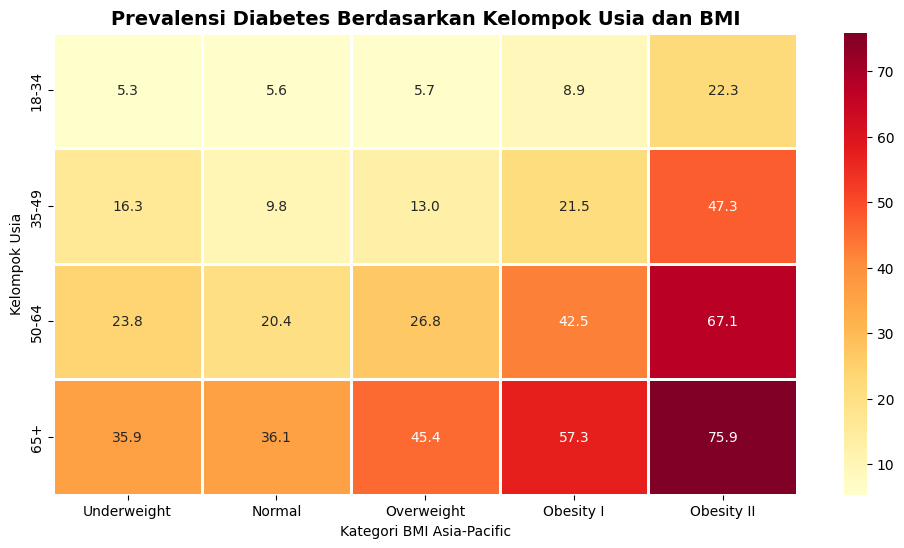

In [ ]:
# =========================================================
# HEATMAP PREVALENSI DIABETES
# =========================================================

# =========================================================
# URUTAN KATEGORI
# =========================================================

age_order = [
    '18-34',
    '35-49',
    '50-64',
    '65+'
]

bmi_order = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obesity I',
    'Obesity II'
]

df['Age_Group'] = pd.Categorical(
    df['Age_Group'],
    categories=age_order,
    ordered=True
)

df['BMI_Category'] = pd.Categorical(
    df['BMI_Category'],
    categories=bmi_order,
    ordered=True
)

# =========================================================
# HITUNG PREVALENSI DIABETES
# =========================================================

heatmap_data = pd.crosstab(
    df['Age_Group'],
    df['BMI_Category'],
    values=df['Diabetes_binary'],
    aggfunc='mean'
) * 100

heatmap_data = heatmap_data.round(1)

print("="*60)
print("PREVALENSI DIABETES BERDASARKAN USIA DAN BMI")
print("="*60)

display(heatmap_data)

# =========================================================
# VISUALISASI HEATMAP
# =========================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=1,
    linecolor='white'
)

plt.title(
    'Prevalensi Diabetes Berdasarkan Kelompok Usia dan BMI',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Kategori BMI Asia-Pacific')
plt.ylabel('Kelompok Usia')

plt.show()

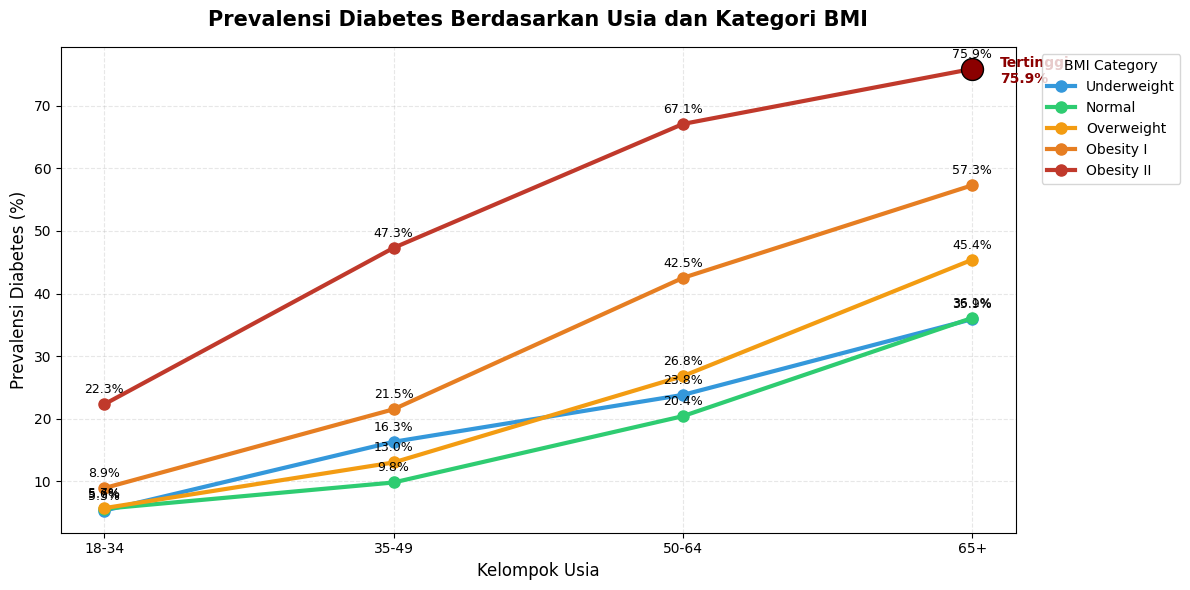

In [ ]:
# =========================================================
# MULTI-LINE CHART USIA vs BMI
# =========================================================

bmi_trend = pd.crosstab(
    df['Age_Group'],
    df['BMI_Category'],
    values=df['Diabetes_binary'],
    aggfunc='mean'
) * 100

bmi_trend = bmi_trend.round(1)

plt.figure(figsize=(12,6))

colors = [
    '#3498DB',
    '#2ECC71',
    '#F39C12',
    '#E67E22',
    '#C0392B'
]

for i, col in enumerate(bmi_trend.columns):

    plt.plot(
        bmi_trend.index,
        bmi_trend[col],
        marker='o',
        linewidth=3,
        markersize=8,
        color=colors[i],
        label=col
    )

    # Tambahkan label angka
    for x, y in zip(
        bmi_trend.index,
        bmi_trend[col]
    ):

        plt.annotate(
            f'{y:.1f}%',
            (x, y),
            textcoords='offset points',
            xytext=(0,8),
            ha='center',
            fontsize=9
        )

plt.title(
    'Prevalensi Diabetes Berdasarkan Usia dan Kategori BMI',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Kelompok Usia',
    fontsize=12
)

plt.ylabel(
    'Prevalensi Diabetes (%)',
    fontsize=12
)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='BMI Category',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

max_val = bmi_trend.max().max()

for col in bmi_trend.columns:

    for x, y in zip(
        bmi_trend.index,
        bmi_trend[col]
    ):

        if y == max_val:

            plt.scatter(
                x,
                y,
                s=250,
                color='darkred',
                edgecolor='black',
                zorder=10
            )

            plt.annotate(
                f'Tertinggi\n{y:.1f}%',
                (x,y),
                textcoords='offset points',
                xytext=(20,-10),
                fontsize=10,
                fontweight='bold',
                color='darkred'
            )

plt.tight_layout()

plt.show()

Q3 — Demografis Usia dan BMI

Insight

Heatmap menunjukkan pola yang sangat jelas bahwa prevalensi diabetes meningkat seiring bertambahnya usia dan meningkatnya kategori BMI.

Pada kelompok usia 18–34 tahun, prevalensi diabetes berada pada kisaran 5,3%–5,7% untuk kategori underweight hingga overweight. Namun pada kategori Obesity II, prevalensi meningkat menjadi 22,3%.

Pada kelompok usia 35–49 tahun, prevalensi diabetes meningkat dari 9,8% pada BMI normal menjadi 47,3% pada kategori Obesity II. Artinya, hampir separuh individu dalam kelompok tersebut merupakan penderita diabetes.

Pola yang sama terlihat pada kelompok usia 50–64 tahun. Prevalensi diabetes meningkat dari 20,4% pada BMI normal menjadi 67,1% pada kategori Obesity II.

Kelompok dengan prevalensi tertinggi ditemukan pada usia 65 tahun ke atas dengan kategori Obesity II, yaitu sebesar 75,9%. Dengan kata lain, sekitar tiga dari empat individu pada kelompok tersebut merupakan penderita diabetes.

Sebaliknya, kelompok dengan prevalensi terendah ditemukan pada usia 18–34 tahun dengan BMI underweight atau normal yang hanya memiliki prevalensi sekitar 5%.

Perbedaan antara kelompok risiko terendah dan tertinggi mencapai lebih dari 70 poin persentase. Temuan ini menunjukkan bahwa kelompok usia yang lebih tua dan kategori BMI yang lebih tinggi secara konsisten memiliki prevalensi diabetes yang lebih besar dibandingkan kelompok lainnya.

Implikasi Bisnis

Usia dan BMI merupakan variabel yang sangat efektif dalam mengidentifikasi kelompok risiko tinggi maupun risiko rendah. Selain itu, kedua variabel ini mudah diperoleh tanpa pemeriksaan laboratorium sehingga sangat cocok digunakan dalam sistem skrining diabetes berbasis web atau aplikasi.

Kesimpulan

Prevalensi diabetes meningkat secara konsisten pada kelompok usia yang lebih tinggi dan kategori BMI yang lebih tinggi. Kelompok usia 65 tahun ke atas dengan BMI Obesity II merupakan kelompok dengan prevalensi diabetes tertinggi pada dataset BRFSS 2015.

# Q4 — Komorbiditas Klinis

## Pertanyaan Bisnis

Seberapa besar pengaruh akumulasi komorbiditas klinis terhadap probabilitas diabetes?

## Tujuan Analisis

Analisis ini bertujuan untuk mengevaluasi hubungan antara jumlah penyakit penyerta yang dimiliki responden dengan prevalensi diabetes.

Dengan memahami pola ini, dapat diketahui apakah risiko diabetes meningkat secara bertahap seiring bertambahnya jumlah komorbiditas.

## Metode Analisis

Dibentuk sebuah variabel baru bernama metabolic_risk_score yang merupakan akumulasi dari beberapa kondisi klinis utama, yaitu:

- HighBP
- HighChol
- Stroke
- HeartDiseaseorAttack

Prevalensi diabetes dihitung pada setiap tingkat komorbiditas dan hubungan antara skor risiko metabolik dengan diabetes diukur menggunakan korelasi Pearson.

PREVALENSI DIABETES BERDASARKAN KOMORBIDITAS


,Jumlah Komorbiditas,Prevalensi Diabetes (%)
0,0,19.093681
1,1,46.192277
2,2,69.451217
3,3,77.966817
4,4,84.022825


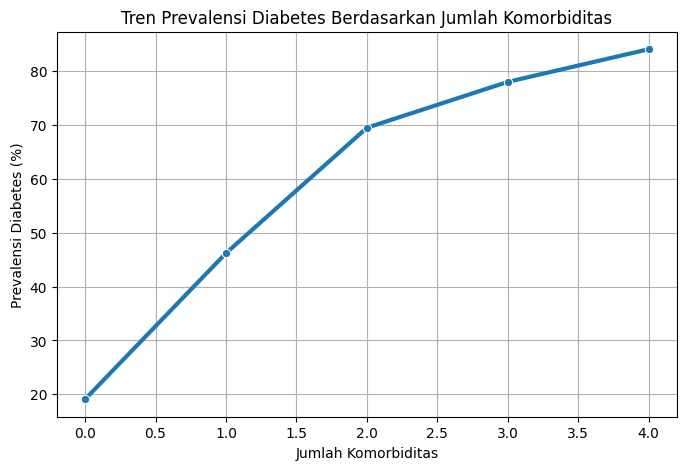

KORELASI METABOLIC RISK SCORE


,metabolic_risk_score,Diabetes_binary
metabolic_risk_score,1.000000,0.424778
Diabetes_binary,0.424778,1.000000


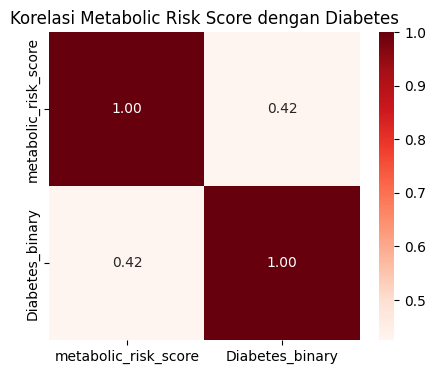

In [ ]:
# =========================================================
# Q4 — KOMORBIDITAS KLINIS
# =========================================================

# Membuat metabolic risk score
df['metabolic_risk_score'] = (
    df['HighBP'] +
    df['HighChol'] +
    df['HeartDiseaseorAttack'] +
    df['Stroke']
)

# =========================================================
# PREVALENSI DIABETES BERDASARKAN JUMLAH KOMORBIDITAS
# =========================================================

risk_table = df.groupby(
    'metabolic_risk_score'
)['Diabetes_binary'].mean() * 100

risk_table = risk_table.reset_index()

risk_table.columns = [
    'Jumlah Komorbiditas',
    'Prevalensi Diabetes (%)'
]

print("="*60)
print("PREVALENSI DIABETES BERDASARKAN KOMORBIDITAS")
print("="*60)

display(risk_table)

# =========================================================
# VISUALISASI TREN RISIKO
# =========================================================

plt.figure(figsize=(8,5))

sns.lineplot(
    data=risk_table,
    x='Jumlah Komorbiditas',
    y='Prevalensi Diabetes (%)',
    marker='o',
    linewidth=3
)

plt.title('Tren Prevalensi Diabetes Berdasarkan Jumlah Komorbiditas')
plt.xlabel('Jumlah Komorbiditas')
plt.ylabel('Prevalensi Diabetes (%)')

plt.grid(True)

plt.show()

# =========================================================
# KORELASI METABOLIC RISK SCORE
# =========================================================

correlation = df[
    ['metabolic_risk_score', 'Diabetes_binary']
].corr()

print("="*60)
print("KORELASI METABOLIC RISK SCORE")
print("="*60)

display(correlation)

# Visualisasi heatmap korelasi
plt.figure(figsize=(5,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)

plt.title('Korelasi Metabolic Risk Score dengan Diabetes')

plt.show()


##Insight

Analisis menunjukkan adanya hubungan yang sangat kuat antara jumlah komorbiditas klinis dan prevalensi diabetes.

Kelompok yang tidak memiliki komorbiditas memiliki prevalensi diabetes sebesar 19,09%. Ketika individu memiliki satu komorbiditas, prevalensi diabetes meningkat menjadi 46,19%.

Peningkatan tersebut berlanjut secara konsisten menjadi 69,45% pada dua komorbiditas, 77,97% pada tiga komorbiditas, dan mencapai 84,02% pada empat komorbiditas.

Pola peningkatan yang konsisten pada seluruh tingkatan komorbiditas menunjukkan bahwa individu dengan lebih banyak kondisi klinis cenderung lebih sering ditemukan pada kelompok diabetes dibandingkan individu dengan kondisi klinis yang lebih sedikit.

Selain itu, metabolic_risk_score memiliki korelasi sebesar 0,4248 terhadap Diabetes_binary. Nilai ini merupakan korelasi tertinggi yang diperoleh dari fitur hasil rekayasa yang dibuat pada tahap Feature Engineering dan bahkan sedikit lebih tinggi dibandingkan GenHlth (0,4076).

Hasil tersebut menunjukkan bahwa penggabungan beberapa indikator klinis ke dalam satu skor mampu menghasilkan hubungan yang lebih kuat terhadap status diabetes dibandingkan sebagian besar fitur tunggal.

###Implikasi Bisnis

Metabolic Risk Score dapat digunakan sebagai indikator risiko yang mudah dipahami dan mampu merangkum beberapa kondisi klinis ke dalam satu ukuran yang lebih sederhana. Hal ini berpotensi membantu pengguna maupun tenaga kesehatan dalam memahami tingkat risiko diabetes secara lebih cepat.

###Kesimpulan

Akumulasi komorbiditas klinis memiliki hubungan yang sangat kuat dengan prevalensi diabetes. Semakin banyak komorbiditas yang dimiliki individu, semakin tinggi prevalensi diabetes yang ditemukan pada kelompok tersebut.

# Q5 — Sosial-Ekonomi dan Akses Kesehatan

## Pertanyaan Bisnis

Apakah individu dengan pendapatan rendah dan hambatan biaya kesehatan memiliki prevalensi diabetes lebih tinggi?

## Tujuan Analisis

Analisis ini bertujuan untuk mengevaluasi apakah faktor sosial-ekonomi dan akses terhadap layanan kesehatan berhubungan dengan prevalensi diabetes.

Selain faktor klinis dan gaya hidup, faktor ekonomi dapat memengaruhi kemampuan individu dalam memperoleh layanan kesehatan, melakukan pemeriksaan rutin, dan menjalankan upaya pencegahan penyakit.

## Metode Analisis

Prevalensi diabetes dihitung pada setiap kategori pendapatan untuk mengidentifikasi pola hubungan antara tingkat ekonomi dan diabetes.

Selanjutnya dilakukan uji Chi-Square terhadap variabel hambatan biaya kesehatan (NoDocbcCost) untuk mengetahui apakah terdapat hubungan yang signifikan antara keterbatasan akses layanan kesehatan dan status diabetes.

In [ ]:

# =========================================================
# LOAD DATA TAMBAHAN
# =========================================================

# Reload dataset asli karena Income dan NoDocbcCost tidak masuk seleksi awal

df_full = pd.read_csv(url)

social_df = df_full[['Income', 'NoDocbcCost', 'Diabetes_binary']]

display(social_df.head())


,Income,NoDocbcCost,Diabetes_binary
0,8,0,0
1,8,0,0
2,8,0,0
3,8,0,0
4,8,0,0


In [ ]:
# =========================================================
# PREVALENSI BERDASARKAN INCOME
# =========================================================

income_table = social_df.groupby('Income')['Diabetes_binary'].mean() * 100

income_table = income_table.reset_index()

income_table.columns = [
    'Income Level',
    'Prevalensi Diabetes (%)'
]

display(income_table)

,Income Level,Prevalensi Diabetes (%)
0,1,65.992800
1,2,68.608270
2,3,64.207306
3,4,60.889156
4,5,56.229713
5,6,51.433849
6,7,46.083151
7,8,34.849365


In [ ]:

# =========================================================
# CHI-SQUARE TEST
# =========================================================

contingency_income = pd.crosstab(
    social_df['NoDocbcCost'],
    social_df['Diabetes_binary']
)

chi2, p, dof, expected = chi2_contingency(contingency_income)

print("="*60)
print("HASIL CHI-SQUARE TEST")
print("="*60)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p:.6f}")


HASIL CHI-SQUARE TEST
Chi-square statistic : 118.4167
P-value              : 0.000000



## Interpretasi

Jika p-value < 0.05:
- terdapat hubungan signifikan antara hambatan biaya kesehatan dan diabetes.

Analisis ini relevan untuk konteks Indonesia:
- masih banyak masyarakat menunda pengobatan karena keterbatasan biaya.


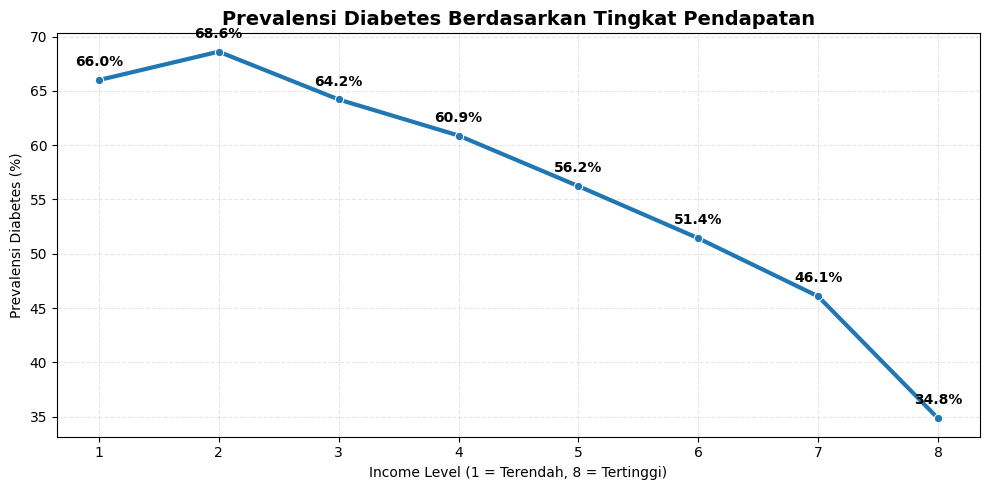

In [ ]:

# =========================================================
# PREVALENSI BERDASARKAN INCOME
# =========================================================


plt.figure(figsize=(10,5))

ax = sns.lineplot(
    data=income_table,
    x='Income Level',
    y='Prevalensi Diabetes (%)',
    marker='o',
    linewidth=3
)

# Tambahkan label angka pada tiap titik
for x, y in zip(
    income_table['Income Level'],
    income_table['Prevalensi Diabetes (%)']
):

    plt.annotate(
        f'{y:.1f}%',
        (x, y),
        textcoords='offset points',
        xytext=(0,10),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Prevalensi Diabetes Berdasarkan Tingkat Pendapatan',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Income Level (1 = Terendah, 8 = Tertinggi)'
)

plt.ylabel(
    'Prevalensi Diabetes (%)'
)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

##Insight

Hasil analisis menunjukkan adanya hubungan yang konsisten antara tingkat pendapatan dan prevalensi diabetes.

Kelompok dengan pendapatan terendah memiliki prevalensi diabetes sebesar 65,99%, sedangkan kelompok dengan pendapatan tertinggi memiliki prevalensi diabetes sebesar 34,85%.

Perbedaan sebesar 31,14 poin persentase menunjukkan bahwa prevalensi diabetes pada kelompok pendapatan rendah hampir dua kali lebih tinggi dibandingkan kelompok pendapatan tinggi.

Pola yang diamati juga cukup konsisten. Setelah mencapai nilai tertinggi pada Income Level 2 sebesar 68,61%, prevalensi diabetes cenderung menurun seiring meningkatnya kategori pendapatan hingga mencapai titik terendah pada Income Level 8.

Selain itu, hasil uji Chi-Square terhadap variabel NoDocbcCost menunjukkan p-value < 0,001. Hasil tersebut menunjukkan bahwa terdapat hubungan yang signifikan secara statistik antara hambatan biaya kesehatan dan status diabetes pada populasi yang diamati.

Temuan ini menunjukkan bahwa faktor sosial-ekonomi dan akses layanan kesehatan memiliki hubungan yang nyata dengan prevalensi diabetes dalam dataset BRFSS 2015.

Implikasi Bisnis

Informasi mengenai tingkat pendapatan dan hambatan biaya kesehatan dapat memberikan informasi tambahan yang tidak sepenuhnya tercermin oleh indikator klinis. Oleh karena itu, kedua variabel tersebut layak dipertahankan sebagai bagian dari sistem skrining risiko diabetes.

Kesimpulan

Individu dengan tingkat pendapatan yang lebih rendah dan hambatan biaya kesehatan yang lebih besar cenderung memiliki prevalensi diabetes yang lebih tinggi dibandingkan kelompok dengan kondisi ekonomi yang lebih baik. Faktor sosial-ekonomi terbukti memiliki hubungan yang signifikan dengan status diabetes pada dataset yang dianalisis.

#Kesimpulan Akhir Exploratory Data Analysis (EDA)

Berdasarkan analisis eksploratif terhadap dataset BRFSS 2015 Diabetes Health Indicators, ditemukan bahwa diabetes merupakan kondisi yang dipengaruhi oleh kombinasi faktor klinis, gaya hidup, demografis, dan sosial-ekonomi. Tidak terdapat satu faktor tunggal yang sepenuhnya menjelaskan kejadian diabetes, melainkan interaksi berbagai indikator kesehatan yang secara bersama-sama meningkatkan risiko seseorang mengalami diabetes.

Dari sisi faktor risiko utama, variabel GenHlth (kondisi kesehatan umum), HighBP (hipertensi), BMI, HighChol (kolesterol tinggi), dan Age (usia) merupakan faktor yang memiliki hubungan paling kuat dengan status diabetes. Temuan ini menunjukkan bahwa kondisi metabolik dan kesehatan fisik secara keseluruhan memiliki peran yang lebih besar dibandingkan faktor perilaku individual dalam membedakan penderita dan non-penderita diabetes.

Analisis gaya hidup dan kebiasaan menunjukkan bahwa individu yang tidak aktif secara fisik dan tidak rutin mengonsumsi sayuran memiliki prevalensi diabetes yang jauh lebih tinggi dibandingkan individu yang aktif dan memiliki pola makan yang lebih sehat. Hasil uji statistik juga mengonfirmasi bahwa hubungan tersebut signifikan, sehingga aktivitas fisik dan pola konsumsi makanan sehat dapat dianggap sebagai faktor protektif terhadap diabetes.

Pada aspek demografis, prevalensi diabetes meningkat secara konsisten seiring bertambahnya usia dan meningkatnya kategori BMI. Risiko tertinggi ditemukan pada kelompok usia lanjut dengan kategori obesitas. Temuan ini mengindikasikan bahwa proses penuaan dan obesitas memberikan efek kumulatif yang secara signifikan meningkatkan kemungkinan seseorang menderita diabetes.

Analisis komorbiditas klinis menunjukkan pola yang sangat kuat antara jumlah penyakit penyerta dan prevalensi diabetes. Individu yang memiliki lebih banyak komorbiditas seperti hipertensi, kolesterol tinggi, penyakit jantung, dan stroke menunjukkan probabilitas diabetes yang jauh lebih tinggi. Dengan kata lain, diabetes cenderung muncul sebagai bagian dari kumpulan gangguan metabolik dan kardiovaskular yang saling berkaitan.

Dari sisi sosial-ekonomi dan akses kesehatan, kelompok dengan pendapatan lebih rendah dan individu yang mengalami hambatan biaya dalam memperoleh layanan kesehatan memiliki prevalensi diabetes yang lebih tinggi. Hasil ini menunjukkan bahwa faktor ekonomi tidak hanya memengaruhi kualitas hidup, tetapi juga berkontribusi terhadap risiko penyakit kronis melalui keterbatasan akses terhadap pencegahan, diagnosis dini, dan pengelolaan kesehatan.

Secara keseluruhan, hasil EDA menunjukkan bahwa profil individu dengan risiko diabetes tertinggi adalah mereka yang berusia lebih tua, memiliki BMI tinggi (obesitas), mengalami hipertensi dan kolesterol tinggi, memiliki beberapa komorbiditas klinis, menjalani gaya hidup kurang sehat, serta berada pada kondisi sosial-ekonomi yang kurang menguntungkan. Sebaliknya, individu yang aktif secara fisik, menjaga pola makan sehat, memiliki kondisi kesehatan umum yang baik, serta akses kesehatan yang lebih memadai cenderung memiliki prevalensi diabetes yang lebih rendah.

Ringkasan Temuan Utama
Kondisi kesehatan umum dan hipertensi merupakan faktor yang paling kuat terkait dengan diabetes.
Aktivitas fisik dan konsumsi sayuran berhubungan dengan penurunan prevalensi diabetes secara signifikan.
Prevalensi diabetes meningkat seiring bertambahnya usia dan kategori BMI.
Akumulasi komorbiditas klinis secara drastis meningkatkan probabilitas diabetes.
Pendapatan rendah dan hambatan biaya kesehatan berkaitan dengan prevalensi diabetes yang lebih tinggi.
Diabetes merupakan masalah kesehatan multidimensi yang dipengaruhi oleh faktor klinis, perilaku, demografis, dan sosial-ekonomi secara bersamaan.
Implikasi Praktis

Temuan ini menunjukkan bahwa upaya pencegahan diabetes sebaiknya difokuskan pada:

Pengendalian berat badan dan obesitas.
Pencegahan serta pengelolaan hipertensi dan kolesterol tinggi.
Peningkatan aktivitas fisik masyarakat.
Edukasi pola makan sehat.
Deteksi dini pada kelompok usia lanjut.
Peningkatan akses layanan kesehatan bagi kelompok berpendapatan rendah.

Dengan demikian, strategi pencegahan diabetes yang paling efektif bukan hanya berfokus pada perubahan perilaku individu, tetapi juga perlu mempertimbangkan faktor kesehatan klinis dan kondisi sosial-ekonomi yang memengaruhi risiko diabetes dalam populasi.